In [1]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the data
data = pd.read_csv("austin_weather.csv")

data.head()

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,...,30.33,30.27,10,10,7,10,2,16,T,


In [3]:
# drop unnecessary columns
data = data.drop(["Events","Date","SeaLevelPressureLowInches"], axis=1)

# replace unwanted symbols
data = data.replace("T", 0.0)
data = data.replace("-", 0.0)

data.head()

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,74,60,45,67,49,43,93,75,57,29.86,29.68,10,7,2,20,4,31,0.46
1,56,48,39,43,36,28,93,68,43,30.41,30.13,10,10,5,16,6,25,0
2,58,45,32,31,27,23,76,52,27,30.56,30.49,10,10,10,8,3,12,0
3,61,46,31,36,28,21,89,56,22,30.56,30.45,10,10,7,12,4,20,0
4,58,50,41,44,40,36,86,71,56,30.41,30.33,10,10,7,10,2,16,0.0


In [4]:
data.to_csv("austin_weather_final.csv", index=False)

In [5]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv("austin_weather_final.csv")

data.head()

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,74,60,45,67.0,49.0,43.0,93.0,75.0,57.0,29.86,29.68,10.0,7.0,2.0,20.0,4.0,31.0,0.46
1,56,48,39,43.0,36.0,28.0,93.0,68.0,43.0,30.41,30.13,10.0,10.0,5.0,16.0,6.0,25.0,0.00
2,58,45,32,31.0,27.0,23.0,76.0,52.0,27.0,30.56,30.49,10.0,10.0,10.0,8.0,3.0,12.0,0.00
3,61,46,31,36.0,28.0,21.0,89.0,56.0,22.0,30.56,30.45,10.0,10.0,7.0,12.0,4.0,20.0,0.00
4,58,50,41,44.0,40.0,36.0,86.0,71.0,56.0,30.41,30.33,10.0,10.0,7.0,10.0,2.0,16.0,0.00


In [7]:
X = data.drop(["PrecipitationSumInches"], axis=1)

Y = data["PrecipitationSumInches"]

In [8]:
Y = Y.values.reshape(-1,1)

In [9]:
day_index = 798

days = [i for i in range(Y.size)]

In [10]:
clf = LinearRegression()

clf.fit(X, Y)

LinearRegression()

The precipitation trend graph:


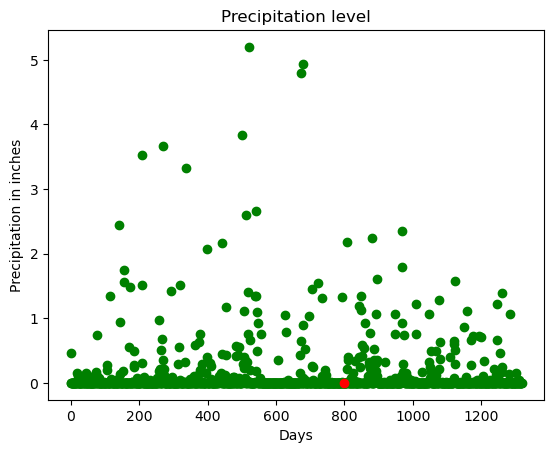

In [11]:
print("The precipitation trend graph:")

plt.scatter(days, Y, color='g')

plt.scatter(days[day_index], Y[day_index], color='r')

plt.title("Precipitation level")

plt.xlabel("Days")

plt.ylabel("Precipitation in inches")

plt.show()

In [12]:
x_vis = X[['VisibilityAvgMiles',
           'WindAvgMPH',
           'TempAvgF',
           'DewPointAvgF',
           'HumidityAvgPercent']]

The precipitation vs attributes trend graph:


ValueError: x and y must be the same size

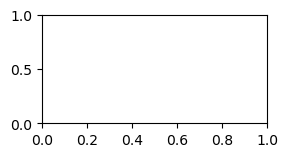

In [13]:
print("The precipitation vs attributes trend graph:")

for i in range(x_vis.columns.size):

    plt.subplot(3,2,i+1)

    plt.scatter(days, x_vis[x_vis.columns.values[i]][:100], color='g')

    plt.scatter(days[day_index], x_vis[x_vis.columns.values[i]][day_index], color='r')

    plt.title(x_vis.columns.values[i])

plt.show()